In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/cs-training.csv')
df.shape

(150000, 12)

In [2]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df = df.drop(columns=['Unnamed: 0'])

In [4]:
df.columns.tolist()

['SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [5]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [6]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [7]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [8]:
# How many rows have the placeholder 96/98 codes?
(df['NumberOfTimes90DaysLate'] >= 96).sum()

np.int64(269)

In [9]:
# How many rows have age = 0?
(df['age'] == 0).sum()

np.int64(1)

In [10]:
# How many rows have absurd utilization (>10, i.e. >1000%)?
(df['RevolvingUtilizationOfUnsecuredLines'] > 10).sum()

np.int64(241)

In [11]:
# How many rows have absurd debt ratio (>10)?
(df['DebtRatio'] > 10).sum()

np.int64(28877)

In [12]:
# Do the extreme DebtRatio rows overlap with missing income?
extreme_debtratio = df[df['DebtRatio'] > 10]

In [13]:
extreme_debtratio['MonthlyIncome'].isnull().sum()

np.int64(26771)

In [14]:
# What fraction of ALL missing-income rows have this extreme DebtRatio pattern?
df[df['MonthlyIncome'].isnull()]['DebtRatio'].describe()

count     29731.000000
mean       1673.396556
std        4248.372895
min           0.000000
25%         123.000000
50%        1159.000000
75%        2382.000000
max      329664.000000
Name: DebtRatio, dtype: float64

In [15]:
# Compare average feature values between defaulters and non-defaulters
df.groupby('SeriousDlqin2yrs')[['age', 'RevolvingUtilizationOfUnsecuredLines', 
                                   'NumberOfTimes90DaysLate', 'DebtRatio']].median()

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate,DebtRatio
SeriousDlqin2yrs,,,,
0,52.0,0.133288,0.0,0.362659
1,45.0,0.838853,0.0,0.428227


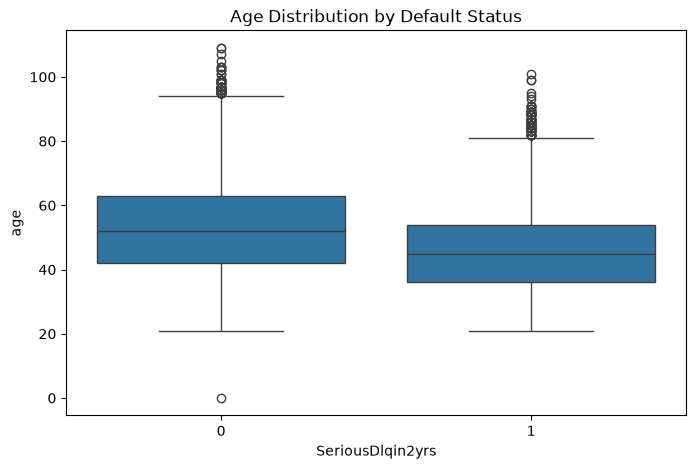

In [16]:
# Visualize age distribution by default status
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='SeriousDlqin2yrs', y='age')
plt.title('Age Distribution by Default Status')
plt.show()

In [17]:
df.groupby('SeriousDlqin2yrs')['NumberOfTimes90DaysLate'].mean()

SeriousDlqin2yrs
0    0.135225
1    2.091362
Name: NumberOfTimes90DaysLate, dtype: float64

In [18]:
df[df['NumberOfTimes90DaysLate'] < 96].groupby('SeriousDlqin2yrs')['NumberOfTimes90DaysLate'].mean()

SeriousDlqin2yrs
0    0.049867
1    0.665047
Name: NumberOfTimes90DaysLate, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(105000, 10) (22500, 10) (22500, 10)


In [20]:
print((X_train['age'] == 0).sum())

0


In [21]:
print((X_val['age'] == 0).sum())

0


In [22]:
print((X_test['age'] == 0).sum())

1


In [23]:
mask = X_test['age'] != 0
X_test = X_test[mask]
y_test = y_test[mask]

# confirm it's gone
print(X_test.shape, y_test.shape)

(22499, 10) (22499,)


In [24]:
cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
        'NumberOfTime60-89DaysPastDueNotWorse', 
        'NumberOfTimes90DaysLate']

# Build a mask: keep only rows where ALL three columns are below 96
train_mask = (X_train[cols] < 96).all(axis=1)
val_mask   = (X_val[cols] < 96).all(axis=1)
test_mask  = (X_test[cols] < 96).all(axis=1)

X_train, y_train = X_train[train_mask], y_train[train_mask]
X_val, y_val     = X_val[val_mask], y_val[val_mask]
X_test, y_test   = X_test[test_mask], y_test[test_mask]

print(X_train.shape, X_val.shape, X_test.shape)

(104818, 10) (22453, 10) (22459, 10)


In [25]:
# Calculate the median from TRAINING data only
income_median = X_train['MonthlyIncome'].median()
dependents_median = X_train['NumberOfDependents'].median()

print(income_median, dependents_median)

5392.0 0.0


In [26]:
# Apply that SAME value to fill all three sets
X_train['MonthlyIncome'] = X_train['MonthlyIncome'].fillna(income_median)
X_val['MonthlyIncome']   = X_val['MonthlyIncome'].fillna(income_median)
X_test['MonthlyIncome']  = X_test['MonthlyIncome'].fillna(income_median)

X_train['NumberOfDependents'] = X_train['NumberOfDependents'].fillna(dependents_median)
X_val['NumberOfDependents']   = X_val['NumberOfDependents'].fillna(dependents_median)
X_test['NumberOfDependents']  = X_test['NumberOfDependents'].fillna(dependents_median)

In [27]:
print(X_train.isnull().sum().sum())

0


In [28]:
print(X_val.isnull().sum().sum())

0


In [29]:
print(X_test.isnull().sum().sum())

0


In [30]:
# How many rows still have an absurd DebtRatio, in each set?
print((X_train['DebtRatio'] > 10).sum())
print((X_val['DebtRatio'] > 10).sum())
print((X_test['DebtRatio'] > 10).sum())

20120
4349
4383


In [31]:
# Calculate cap from TRAINING data only (95th percentile)
debtratio_cap = X_train['DebtRatio'].quantile(0.95)
print(debtratio_cap)

2447.149999999994


In [32]:
# Apply the same cap to all three sets
X_train['DebtRatio'] = X_train['DebtRatio'].clip(upper=debtratio_cap)
X_val['DebtRatio']   = X_val['DebtRatio'].clip(upper=debtratio_cap)
X_test['DebtRatio']  = X_test['DebtRatio'].clip(upper=debtratio_cap)

In [33]:
# Confirm the fix
print((X_train['DebtRatio'] > debtratio_cap).sum())  # should be 0
X_train['DebtRatio'].describe()

0


count    104818.000000
mean        255.253910
std         663.335616
min           0.000000
25%           0.176769
50%           0.368074
75%           0.863420
max        2447.150000
Name: DebtRatio, dtype: float64

In [34]:
Q1 = X_train['DebtRatio'].quantile(0.25)
Q3 = X_train['DebtRatio'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(Q1, Q3, upper_bound)

0.17676929749999998 0.8634195222500001 1.8933948593750003


In [35]:
X_train['DebtRatio'] = X_train['DebtRatio'].clip(upper=upper_bound)
X_val['DebtRatio']   = X_val['DebtRatio'].clip(upper=upper_bound)
X_test['DebtRatio']  = X_test['DebtRatio'].clip(upper=upper_bound)

X_train['DebtRatio'].describe()

count    104818.000000
mean          0.659859
std           0.681067
min           0.000000
25%           0.176769
50%           0.368074
75%           0.863420
max           1.893395
Name: DebtRatio, dtype: float64

In [36]:
Q1_util = X_train['RevolvingUtilizationOfUnsecuredLines'].quantile(0.25)
Q3_util = X_train['RevolvingUtilizationOfUnsecuredLines'].quantile(0.75)
IQR_util = Q3_util - Q1_util
upper_bound_util = Q3_util + 1.5 * IQR_util
print(Q1_util, Q3_util, upper_bound_util)

0.029540765 0.556572025 1.347118915


In [37]:
X_train['RevolvingUtilizationOfUnsecuredLines'] = X_train['RevolvingUtilizationOfUnsecuredLines'].clip(upper=upper_bound_util)
X_val['RevolvingUtilizationOfUnsecuredLines']   = X_val['RevolvingUtilizationOfUnsecuredLines'].clip(upper=upper_bound_util)
X_test['RevolvingUtilizationOfUnsecuredLines']  = X_test['RevolvingUtilizationOfUnsecuredLines'].clip(upper=upper_bound_util)

X_train['RevolvingUtilizationOfUnsecuredLines'].describe()

count    104818.000000
mean          0.320878
std           0.355725
min           0.000000
25%           0.029541
50%           0.152589
75%           0.556572
max           1.347119
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [38]:
for name, X in [('train', X_train), ('val', X_val), ('test', X_test)]:
    print(f"--- {name} ---")
    print(X.isnull().sum().sum(), "missing values")
    print((X['age'] == 0).sum(), "age=0 rows")
    print((X[['NumberOfTime30-59DaysPastDueNotWorse',
               'NumberOfTime60-89DaysPastDueNotWorse',
               'NumberOfTimes90DaysLate']] >= 96).any(axis=1).sum(), "placeholder code rows")
    print((X['DebtRatio'] > upper_bound).sum(), "DebtRatio outliers")
    print((X['RevolvingUtilizationOfUnsecuredLines'] > upper_bound_util).sum(), "Utilization outliers")
    print()

--- train ---
0 missing values
0 age=0 rows
0 placeholder code rows
0 DebtRatio outliers
0 Utilization outliers

--- val ---
0 missing values
0 age=0 rows
0 placeholder code rows
0 DebtRatio outliers
0 Utilization outliers

--- test ---
0 missing values
0 age=0 rows
0 placeholder code rows
0 DebtRatio outliers
0 Utilization outliers



In [39]:
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)

y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)